# Ejercicio 3 — Consumo de energia electrica (regresion lineal multiple)

**Dataset:** `energia_data.csv`

**Variables:** `Temperatura` (°C), `Hora` (1–24), `Dia_Semana` (1=Lunes … 7=Domingo), `Consumo_Energia` (kWh).

**Salidas:** modelo, RMSE/R2, impacto relativo de cada predictor, **graficas de lineas** (consumo **real vs predicho**) y texto de **interpretacion**.


In [35]:
%matplotlib inline

from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


### Configuracion


In [36]:
# --- Configuracion ---
BASE_DIR = Path.cwd().resolve()
DATA_PATH = BASE_DIR / "energia_data.csv"

FEATURE_NAMES: tuple[str, ...] = ("Temperatura", "Hora", "Dia_Semana")
TARGET_NAME: str = "Consumo_Energia"

# Etiquetas Dia_Semana: 1=Lun ... 7=Dom
DIAS_SEMANA_ES: tuple[str, ...] = ("Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom")

SAVE_LINE_TEMP_PATH: Path | None = None   # ej. BASE_DIR / "energia_lineas_temperatura.png"
SAVE_LINE_HORA_PATH: Path | None = None   # ej. BASE_DIR / "energia_lineas_hora.png"
SAVE_LINE_DIA_PATH: Path | None = None     # ej. BASE_DIR / "energia_lineas_diasemana.png"
SAVE_LINE_ORDEN_PATH: Path | None = None   # ej. BASE_DIR / "energia_lineas_orden_semana_hora.png"


### Datos


In [37]:
def cargar_energia(path: Path) -> pd.DataFrame:
    """Carga CSV y valida columnas."""
    if not path.is_file():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    cols = list(FEATURE_NAMES) + [TARGET_NAME]
    if any(c not in df.columns for c in cols):
        raise ValueError("Faltan columnas requeridas.")
    if df[cols].isna().any().any():
        raise ValueError("Hay valores faltantes.")
    return df


### Modelo, RMSE, R2 e impacto


In [38]:
def entrenar_y_evaluar(X: pd.DataFrame, y: pd.Series, *, test_size: float = 0.2, random_state: int = 42):
    """Train/test, ajuste OLS, RMSE y R2."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=True
    )
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    p_tr, p_te = model.predict(X_tr), model.predict(X_te)
    metrics = {
        "rmse_train": float(np.sqrt(mean_squared_error(y_tr, p_tr))),
        "rmse_test": float(np.sqrt(mean_squared_error(y_te, p_te))),
        "r2_train": float(r2_score(y_tr, p_tr)),
        "r2_test": float(r2_score(y_te, p_te)),
    }
    return model, metrics, X_tr


def impacto_por_variable(model: LinearRegression, X_train: pd.DataFrame) -> pd.DataFrame:
    """|coef| * std(train) para comparar impacto entre variables."""
    stds = X_train.std()
    raw = pd.Series(model.coef_, index=FEATURE_NAMES)
    mag = raw.abs() * stds
    out = pd.DataFrame({"coeficiente": raw, "std_train": stds, "impacto_abs_std": mag})
    return out.sort_values("impacto_abs_std", ascending=False)


def imprimir_resultados(model: LinearRegression, metrics: dict, tabla_imp: pd.DataFrame) -> None:
    print("RMSE train:", round(metrics["rmse_train"], 4), "| R2 train:", round(metrics["r2_train"], 4))
    print("RMSE test :", round(metrics["rmse_test"], 4), "| R2 test :", round(metrics["r2_test"], 4))
    print("Intercepto:", round(float(model.intercept_), 4))
    print()
    print(tabla_imp.to_string())
    print()
    print("Mayor impacto (|coef|*std train):", tabla_imp["impacto_abs_std"].idxmax())


### Graficas de lineas (observado vs predicho)


In [39]:
def _plot_lineas_obs_vs_pred_x(
    x: np.ndarray,
    y_obs: np.ndarray,
    y_pred: np.ndarray,
    *,
    xlabel: str,
    title: str,
    save_path: Path | None,
    xticks=None,
    xticklabels=None,
) -> plt.Figure:
    """Lineas ordenadas por x: consumo observado vs predicho (mismo modelo, cada fila)."""
    tdf = pd.DataFrame({"x": x, "obs": y_obs, "pred": y_pred}).sort_values("x").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(tdf["x"], tdf["obs"], label="Consumo observado (kWh)", lw=1.2, color="#1f77b4", alpha=0.9)
    ax.plot(tdf["x"], tdf["pred"], label="Consumo predicho (kWh)", lw=1.2, color="#d62728", alpha=0.85)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Consumo_Energia (kWh)")
    ax.set_title(title)
    ax.legend(loc="best")
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
        print("Guardado:", save_path)
    plt.show()
    return fig


def graficas_lineas_consumo_vs_predictores(
    df: pd.DataFrame,
    y: pd.Series,
    y_pred: np.ndarray,
    *,
    temp: Path | None = None,
    hora: Path | None = None,
    dia: Path | None = None,
    orden: Path | None = None,
) -> None:
    """Tres figuras por variable; la cuarta = semana en eje X (dias, hora como fraccion)."""
    p = {"temp": temp, "hora": hora, "dia": dia, "orden": orden}
    _plot_lineas_obs_vs_pred_x(
        df["Temperatura"].to_numpy(),
        y.to_numpy(),
        y_pred,
        xlabel="Temperatura (C)",
        title="Consumo: observado vs predicho (ordenado por temperatura)",
        save_path=p.get("temp"),
    )
    _plot_lineas_obs_vs_pred_x(
        df["Hora"].to_numpy(),
        y.to_numpy(),
        y_pred,
        xlabel="Hora del dia (1-24)",
        title="Consumo: observado vs predicho (ordenado por hora)",
        save_path=p.get("hora"),
    )
    _plot_lineas_obs_vs_pred_x(
        df["Dia_Semana"].to_numpy(),
        y.to_numpy(),
        y_pred,
        xlabel="Dia de la semana (1=Lun ... 7=Dom)",
        title="Consumo: observado vs predicho (ordenado por Dia_Semana)",
        save_path=p.get("dia"),
        xticks=list(range(1, 8)),
        xticklabels=list(DIAS_SEMANA_ES),
    )
    # Eje X solo visual: [0,7) = semana; cada dia ocupa ancho 1; dentro del dia la hora recorre 0..1
    slot = (
        df.assign(_obs=y.values, _pred=y_pred)
        .groupby(["Dia_Semana", "Hora"], as_index=False)
        .agg(obs=("_obs", "mean"), pred=("_pred", "mean"))
    )
    slot = slot.sort_values(["Dia_Semana", "Hora"]).reset_index(drop=True)
    # x_vis = 0 + 0/24 .. 0 + 23/24 para Lun; 1 + ... para Mar; ... ( mismo orden que antes, reescalado )
    slot["x_vis"] = (slot["Dia_Semana"] - 1) + (slot["Hora"] - 1) / 24.0
    fig, ax = plt.subplots(figsize=(13, 4.2))
    ax.plot(slot["x_vis"], slot["obs"], label="Observado (prom. por dia y hora)", lw=1.4, color="#1f77b4", marker="o", ms=2.5)
    ax.plot(slot["x_vis"], slot["pred"], label="Predicho (prom. por dia y hora)", lw=1.4, color="#d62728", alpha=0.9, marker="o", ms=2.5)
    ax.set_xlim(0, 7)
    ax.set_xticks(np.arange(7) + 0.5)
    ax.set_xticklabels(list(DIAS_SEMANA_ES))
    ax.set_xlabel("Dia de la semana (posicion de la hora dentro de cada banda: 0h a la izquierda del dia, 24h a la derecha)")
    ax.set_ylabel("Consumo (kWh)")
    ax.set_title("Observado vs predicho: una semana en el eje X (cada dia = ancho 1; hora = fraccion dentro del dia)")
    for i in range(1, 7):
        ax.axvline(i, color="0.75", lw=0.8, ls="--", alpha=0.7)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if p.get("orden"):
        fig.savefig(p["orden"], dpi=150)
        print("Guardado:", p["orden"])
    plt.show()


### Como interpretar las graficas de lineas (real vs predicho)

**1) Ordenado por Temperatura, Hora o Dia_Semana**  
El eje X no es el tiempo real de medicion: los puntos se **ordenan** por la variable indicada y se unen lineas. Asi se ve como el consumo **observado** y el **predicho** (mismo modelo en cada fila) cambian al recorrer el rango de esa variable. Si las dos lineas estan cerca, el modelo reproduce bien el patron **marginal** respecto a esa X; separaciones indican error o influencia de las **otras** variables (que tambien varian entre filas con similar temperatura, hora o dia).

**2) Semana en el eje (solo presentacion visual)**  
Eje X de **0 a 7** (0=Lun ... 6=Dom): **cada tramo de ancho 1 es un dia**; la **hora** recorre de izquierda a derecha dentro de ese tramo. Mismas medias por (Dia_Semana, Hora) que antes; solo mejora la **lectura visual** en dias. Lineas punteadas = cambio de dia.


**3) Correlacion vs causalidad**  
Lineas juntas no implican que solo esa variable “cause” el consumo: el modelo usa **tres** variables a la vez.


### Ejecutar


RMSE train: 19.9798 | R2 train: 0.9015
RMSE test : 20.7248 | R2 test : 0.8968
Intercepto: 101.2882

             coeficiente  std_train  impacto_abs_std
Temperatura     9.952866   4.990078        49.665575
Hora            5.019813   6.928324        34.778892
Dia_Semana     -3.031177   2.003933         6.074274

Mayor impacto (|coef|*std train): Temperatura


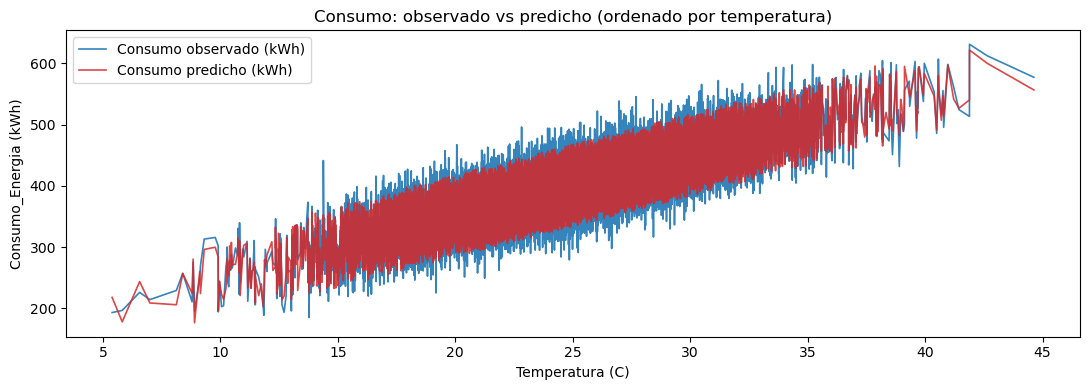

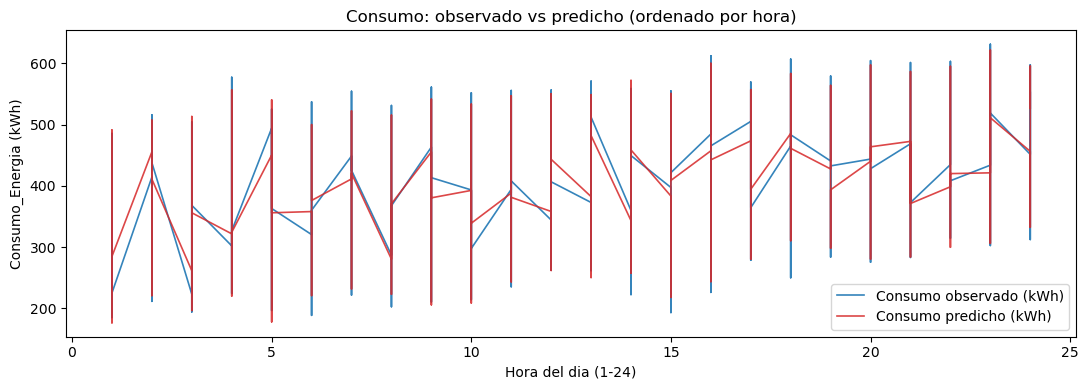

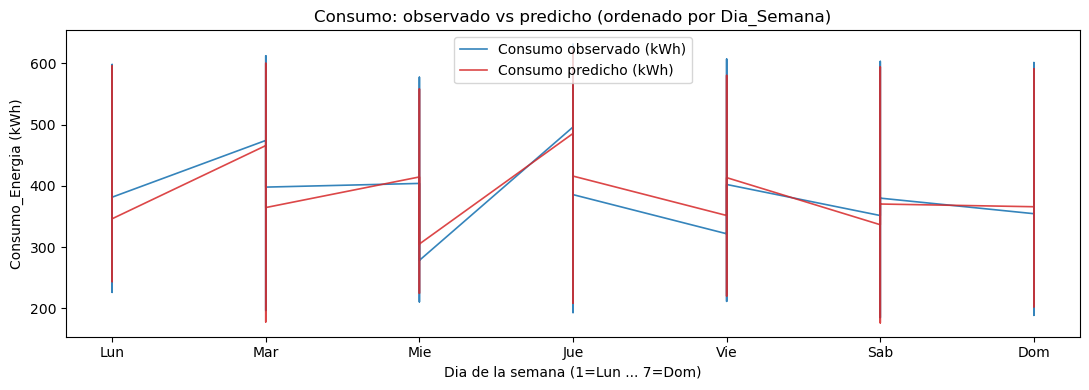

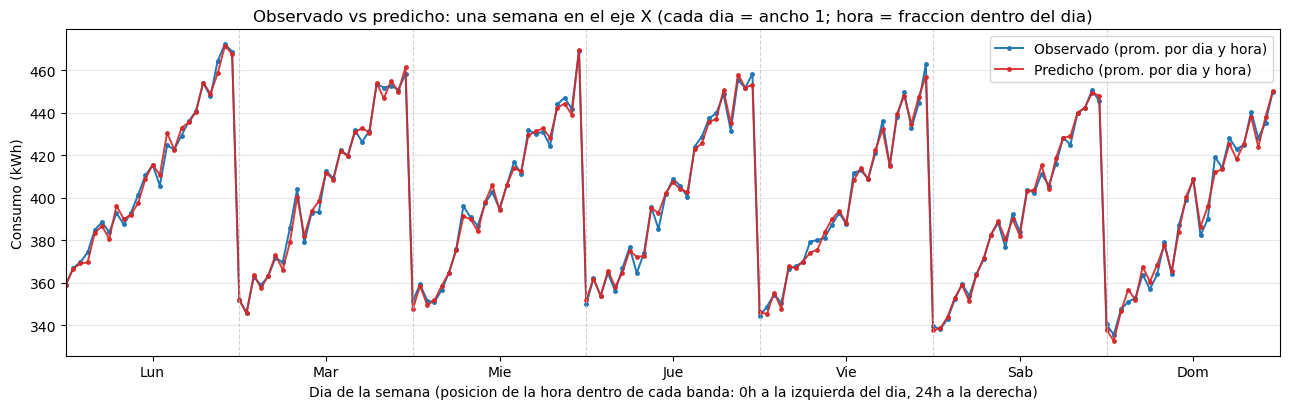

In [40]:
# --- Ejecucion ---
df = cargar_energia(DATA_PATH)
X = df.loc[:, list(FEATURE_NAMES)]
y = df[TARGET_NAME]

model, metrics, X_tr = entrenar_y_evaluar(X, y)
tabla_imp = impacto_por_variable(model, X_tr)
imprimir_resultados(model, metrics, tabla_imp)

y_hat = model.predict(X)  # prediccion en todo el dataset (mismo modelo entrenado arriba)

graficas_lineas_consumo_vs_predictores(
    df,
    y,
    y_hat,
    temp=SAVE_LINE_TEMP_PATH,
    hora=SAVE_LINE_HORA_PATH,
    dia=SAVE_LINE_DIA_PATH,
    orden=SAVE_LINE_ORDEN_PATH,
)


In [41]:
#exportar modelo energia
joblib.dump(model, 'modelo_energia.pkl')
print('Modelo guardado como modelo_energia.pkl')




Modelo guardado como modelo_energia.pkl
